# The Chosen Dataset
- We chose a dataset from the Stack Overflow Developer Survey, which contains information about developers worldwide such as experience, education, job roles, technologies used, and salaries. It is used to analyze trends in the software engineering field and understand factors affecting developers’ careers.

- Source: https://survey.stackoverflow.co/


# Task 1: Exploratory Data Analysis & Visualization

- Imports

In [79]:
import numpy as np
import pandas as pd
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

- Read data
- Select most important features

In [80]:
df = pd.read_csv('stackoverflow_survey.csv')
# df = df.sample(n=10000, random_state=42)
df = df[['Age', 'EdLevel', 'Employment', 'WorkExp',
        'LearnCode', 'YearsCode', 'DevType', 'OrgSize',
        'RemoteWork', 'Industry', 'AIThreat', 'NewRole',
        'AISelect', 'AISent', 'Country', 
        'LanguageAdmired', 'ConvertedCompYearly', 'JobSat']]

# LearnCode, YearsCode, LanguageAdmired ==> Tech Score (Bonus)
# AIThreat, newRule, aiSelect, AiSent ==> Ai Score (Bonus)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_11844\1970156744.py:1: DtypeWarning: Columns (0: ResponseId, 1: DevEnvHaveEntry, 2: SOTagsHaveEntry, 3: SOTagsWant Entry, 4: CommPlatformHaveEntr, 5: CommPlatformWantEntr, 6: AIAgentOrchestration, 7: AIAgentObsWrite) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('stackoverflow_survey.csv')


In [81]:
df.sample(20)

,Age,EdLevel,Employment,WorkExp,LearnCode,YearsCode,DevType,OrgSize,RemoteWork,Industry,AIThreat,NewRole,AISelect,AISent,Country,LanguageAdmired,ConvertedCompYearly,JobSat
6530,55-64 years old,Some college/university study without earning ...,Retired,36.0,Technical documentation (is generated for/by t...,48.0,Other (please specify):,NaN,NaN,NaN,NaN,NaN,"No, but I plan to soon",Unfavorable,United States of America,NaN,NaN,8.0
17747,35-44 years old,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",Employed,12.0,NaN,14.0,"Architect, software or solutions","10,000 or more employees","Hybrid (some remote, leans heavy to in-person)",Fintech,No,I have neither consider or transitioned into a...,"Yes, I use AI tools daily",Favorable,United States of America,Bash/Shell (all shells);C;C++;Fortran;HTML/CSS...,400000.0,9.0
43376,18-24 years old,"Secondary school (e.g. American high school, G...",Student,NaN,NaN,8.0,Student,NaN,NaN,NaN,Yes,I have somewhat considered changing my career ...,"Yes, I use AI tools daily",Favorable,United States of America,NaN,NaN,NaN
2462,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Not employed,2.0,NaN,12.0,Student,NaN,NaN,NaN,No,I have strongly considered changing my career ...,"Yes, I use AI tools monthly or infrequently",Favorable,Canada,C;HTML/CSS;Lisp;Python;TypeScript,NaN,NaN
48267,18-24 years old,"Associate degree (A.A., A.S., etc.)","Independent contractor, freelancer, or self-em...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16693,35-44 years old,"Secondary school (e.g. American high school, G...",Employed,15.0,Online Courses or Certification (includes all ...,15.0,"Developer, full-stack",20 to 99 employees,"Hybrid (some in-person, leans heavy to flexibi...",Manufacturing,I'm not sure,I have strongly considered changing my career ...,"Yes, I use AI tools monthly or infrequently",Favorable,Poland,NaN,75320.0,3.0
4692,45-54 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,26.0,NaN,29.0,Engineering manager,20 to 99 employees,"Hybrid (some remote, leans heavy to in-person)",Higher Education,No,I have neither consider or transitioned into a...,"Yes, I use AI tools weekly",Favorable,United States of America,Bash/Shell (all shells);C#;HTML/CSS;JavaScript...,180000.0,9.0
26074,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,10.0,NaN,15.0,"Developer, full-stack","10,000 or more employees","Hybrid (some in-person, leans heavy to flexibi...","Transportation, or Supply Chain",No,I have transitioned into a new career and/or i...,"No, and I don't plan to",Indifferent,Germany,HTML/CSS;JavaScript,116015.0,5.0
22692,55-64 years old,Other (please specify):,"Independent contractor, freelancer, or self-em...",40.0,NaN,41.0,"Developer, full-stack","Just me - I am a freelancer, sole proprietor, ...",Remote,Software Development,No,I have neither consider or transitioned into a...,"No, and I don't plan to",Very unfavorable,Germany,NaN,NaN,10.0
25667,45-54 years old,Some college/university study without earning ...,"Independent contractor, freelancer, or self-em...",25.0,Online Courses or Certification (includes all ...,33.0,"Developer, back-end",NaN,NaN,Healthcare,Yes,I have somewhat considered changing my career ...,"Yes, I use AI tools daily",Indifferent,Poland,Python;SQL,160000.0,3.0


In [82]:
df.dtypes

Age                        str
EdLevel                    str
Employment                 str
WorkExp                float64
LearnCode                  str
YearsCode              float64
DevType                    str
OrgSize                    str
RemoteWork                 str
Industry                   str
AIThreat                   str
NewRole                    str
AISelect                   str
AISent                     str
Country                    str
LanguageAdmired            str
ConvertedCompYearly    float64
JobSat                 float64
dtype: object

In [83]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49196 entries, 0 to 49195
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  49190 non-null  str    
 1   EdLevel              48148 non-null  str    
 2   Employment           48338 non-null  str    
 3   WorkExp              42892 non-null  float64
 4   LearnCode            33556 non-null  str    
 5   YearsCode            43041 non-null  float64
 6   DevType              43679 non-null  str    
 7   OrgSize              34177 non-null  str    
 8   RemoteWork           33779 non-null  str    
 9   Industry             33641 non-null  str    
 10  AIThreat             36077 non-null  str    
 11  NewRole              35526 non-null  str    
 12  AISelect             33719 non-null  str    
 13  AISent               33466 non-null  str    
 14  Country              35436 non-null  str    
 15  LanguageAdmired      23469 non-null  str    
 1

In [84]:
df.describe()

,WorkExp,YearsCode,ConvertedCompYearly,JobSat
count,42892.000000,43041.000000,2.394600e+04,26669.000000
mean,13.367551,16.571037,1.017630e+05,7.201845
std,10.800199,11.787691,4.617665e+05,1.997209
min,1.000000,1.000000,1.000000e+00,0.000000
25%,5.000000,8.000000,3.817100e+04,6.000000
50%,10.000000,14.000000,7.532000e+04,8.000000
75%,20.000000,24.000000,1.205980e+05,8.000000
max,100.000000,100.000000,5.000000e+07,10.000000


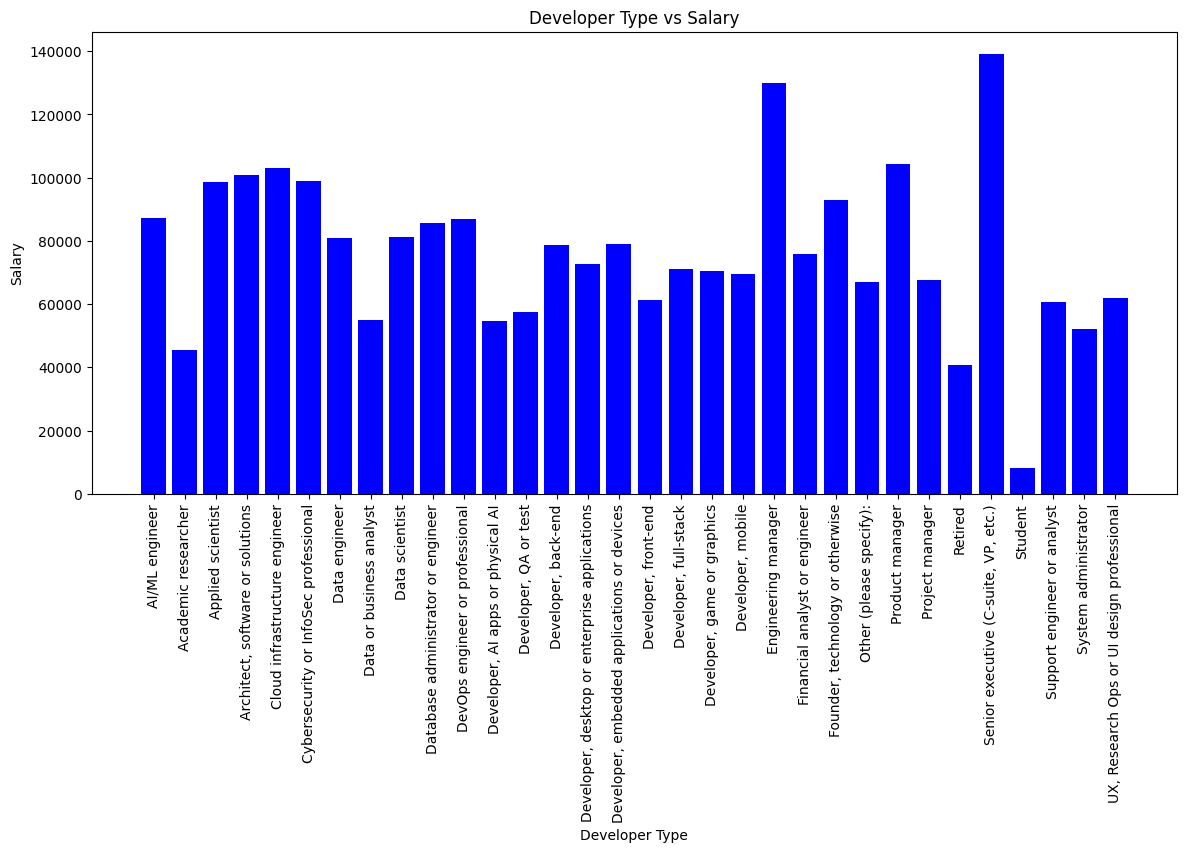

In [85]:
plt.figure(figsize=(14,6))
salaryByType = df.groupby('DevType')['ConvertedCompYearly'].median()
plt.bar(salaryByType.index, salaryByType.values, color="blue")
plt.title("Developer Type vs Salary")
plt.xlabel("Developer Type")
plt.xticks(rotation=90)
plt.ylabel("Salary")
plt.show()

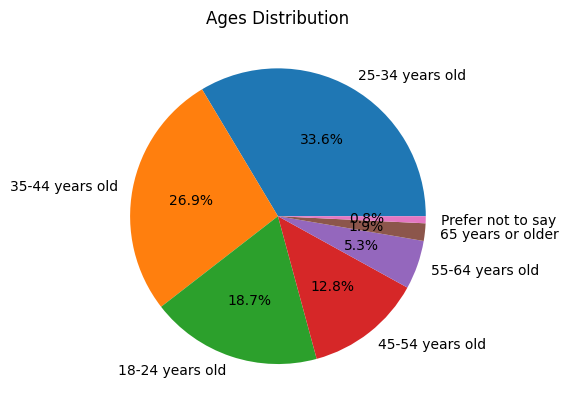

In [86]:
plt.pie(df["Age"].value_counts(), labels=df["Age"].value_counts().index, autopct="%1.1f%%")
plt.title("Ages Distribution")
plt.show()

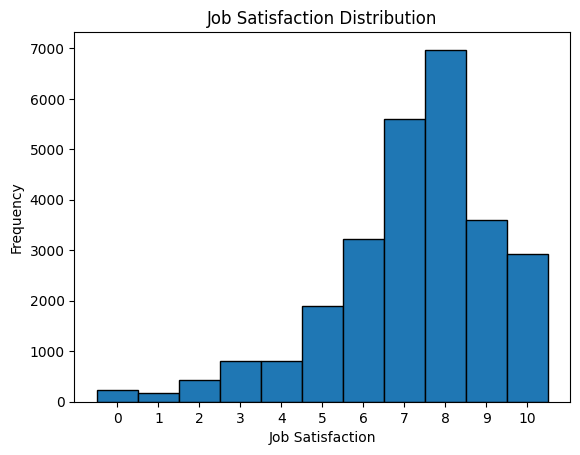

In [87]:
plt.hist(df["JobSat"], bins=np.arange(-0.5, 11.5, 1), edgecolor='black')
plt.title("Job Satisfaction Distribution")
plt.xlabel("Job Satisfaction")
plt.ylabel("Frequency")
plt.xticks(range(11))
plt.show()

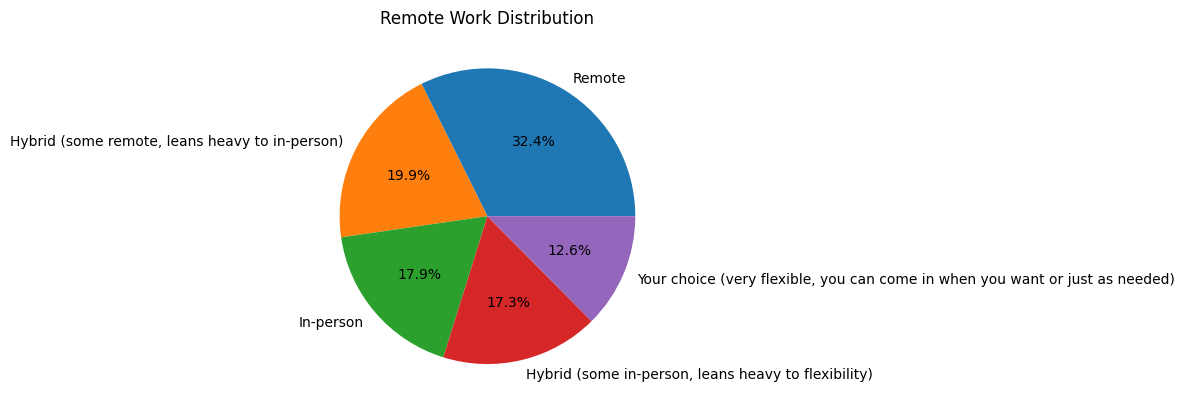

In [88]:
plt.pie(df["RemoteWork"].value_counts(), labels=df["RemoteWork"].value_counts().index, autopct="%1.1f%%")
plt.title("Remote Work Distribution")
plt.show()

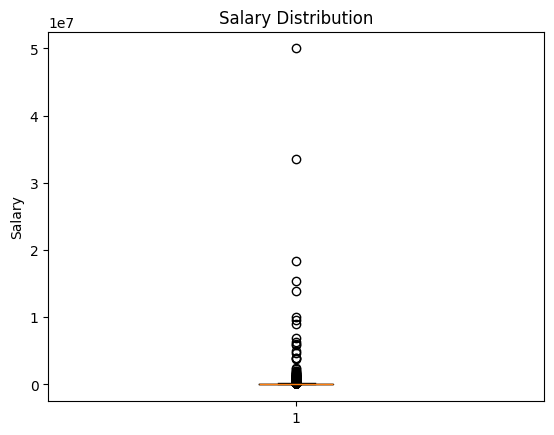

In [89]:
plt.boxplot(df["ConvertedCompYearly"].dropna())
plt.title("Salary Distribution")
plt.ylabel("Salary")
plt.show()

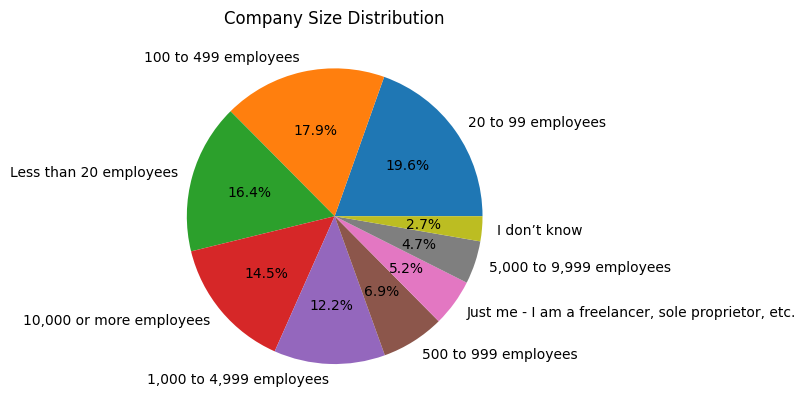

In [90]:
plt.pie(df["OrgSize"].value_counts(), labels=df["OrgSize"].value_counts().index, autopct="%1.1f%%")
plt.title("Company Size Distribution")
plt.show()

# Task 2: Data Preprocessing 

### Remove duplicate rows

In [91]:
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)
print(df.duplicated().sum())

2923
0


### Handle missing values

In [92]:
df.isnull().sum()

Age                        1
EdLevel                  174
Employment                 8
WorkExp                 4310
LearnCode              12759
YearsCode               3249
DevType                 2609
OrgSize                12100
RemoteWork             12498
Industry               12632
AIThreat               10196
NewRole                10747
AISelect               12554
AISent                 12807
Country                10837
LanguageAdmired        22804
ConvertedCompYearly    22327
JobSat                 19604
dtype: int64

In [93]:
df.dropna(subset=['LanguageAdmired', 'AISelect', 'AISent', 'AIThreat', 'NewRole', 'ConvertedCompYearly', 'YearsCode', 'LearnCode', 'JobSat'], axis=0, inplace=True)

In [94]:
# Numerical Columns (Median)
num_cols = ['WorkExp']

for col in num_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

# Categories Columns (Mod)
cat_cols = ['OrgSize', 'RemoteWork', 'Industry' , 'WorkExp',  'EdLevel']

for col in cat_cols:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)


In [95]:
df.isnull().sum()

Age                    0
EdLevel                0
Employment             0
WorkExp                0
LearnCode              0
YearsCode              0
DevType                0
OrgSize                0
RemoteWork             0
Industry               0
AIThreat               0
NewRole                0
AISelect               0
AISent                 0
Country                0
LanguageAdmired        0
ConvertedCompYearly    0
JobSat                 0
dtype: int64

### Detecting and treating outliers

IQR outliers in ConvertedCompYearly: 434


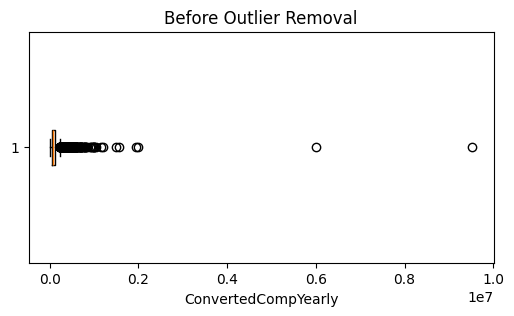

Remaining rows after trimming: 9752


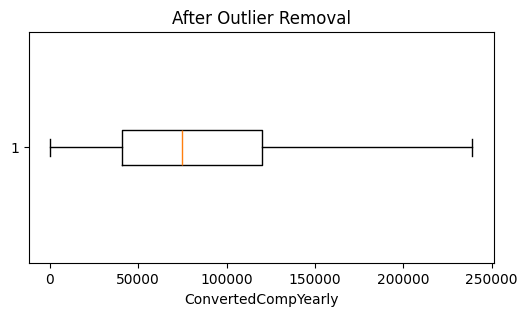

In [96]:
col = "ConvertedCompYearly"

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detect outliers
outliers_iqr = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

print(f'IQR outliers in {col}: {len(outliers_iqr)}')

# Before plot
plt.figure(figsize=(6, 3))
plt.boxplot(df[col], vert=False)
plt.title('Before Outlier Removal')
plt.xlabel(col)
plt.show()

# Remove outliers properly

df[col] = df[col].clip(lower_bound, upper_bound)

print(f"Remaining rows after trimming: {len(df)}")

# After plot
plt.figure(figsize=(6, 3))
plt.boxplot(df[col], vert=False)
plt.title('After Outlier Removal')
plt.xlabel(col)
plt.show()

### Encoding categorical features

- Label Encoding

In [97]:
for col in ['Age', 'EdLevel', 'OrgSize', 'AIThreat']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

- One-Hot Encoding

In [98]:
learncode_encoded = df['LearnCode'].str.get_dummies(sep=';')
learncode_encoded.columns = [f"LearnCode_{col.strip()}" for col in learncode_encoded.columns]
df = pd.concat([df.drop(columns=['LearnCode']), learncode_encoded], axis=1)

one_hot_cols = ['Employment', 'DevType', 'RemoteWork', 'Industry', 'NewRole', 'AISelect', 'AISent', 'Country', 'LanguageAdmired']
df = pd.get_dummies(df, columns=one_hot_cols)

### Feature scaling

- Standardization (z-score)

In [99]:
for col in ['WorkExp', 'YearsCode', 'ConvertedCompYearly']:
    std_scaler = MinMaxScaler()
    df[col] = std_scaler.fit_transform(df[[col]])

### Dimensionality Reduction

In [100]:
print([col for col in df.columns if "AISelect" in col])
print([col for col in df.columns if "AISent" in col])
print([col for col in df.columns if "NewRole" in col])

["AISelect_No, and I don't plan to", 'AISelect_No, but I plan to soon', 'AISelect_Yes, I use AI tools daily', 'AISelect_Yes, I use AI tools monthly or infrequently', 'AISelect_Yes, I use AI tools weekly']
['AISent_Favorable', 'AISent_Indifferent', 'AISent_Unfavorable', 'AISent_Unsure', 'AISent_Very favorable', 'AISent_Very unfavorable']
['NewRole_I have neither consider or transitioned into a new career or industry', 'NewRole_I have somewhat considered changing my career and/or the industry I work in', 'NewRole_I have strongly considered changing my career and/or the industry I work in', 'NewRole_I have transitioned into a new career and/or industry involuntarily', 'NewRole_I have transitioned into a new career and/or industry voluntarily']


In [101]:
# Group columns
ai_select_cols = [
    'AISelect_No, and I don\'t plan to',
    'AISelect_No, but I plan to soon',
    'AISelect_Yes, I use AI tools daily',
    'AISelect_Yes, I use AI tools monthly or infrequently',
    'AISelect_Yes, I use AI tools weekly'
]

ai_sent_cols = [
    'AISent_Favorable',
    'AISent_Indifferent',
    'AISent_Unfavorable',
    'AISent_Unsure',
    'AISent_Very favorable',
    'AISent_Very unfavorable'
]

new_role_cols = [
    'NewRole_I have neither consider or transitioned into a new career or industry',
    'NewRole_I have somewhat considered changing my career and/or the industry I work in',
    'NewRole_I have strongly considered changing my career and/or the industry I work in',
    'NewRole_I have transitioned into a new career and/or industry involuntarily',
    'NewRole_I have transitioned into a new career and/or industry voluntarily'
]

# Combine all AI-related columns
ai_cols = ai_select_cols + ai_sent_cols + new_role_cols + ['AIThreat']

ai_features = df[ai_cols]

# Apply PCA (reduce to 1 dimension)
pca = PCA(n_components=1)
df['AIScore'] = pca.fit_transform(ai_features).ravel()

# Drop original columns
df.drop(columns=ai_cols, inplace=True)

In [102]:
df.head()

,Age,EdLevel,WorkExp,YearsCode,OrgSize,ConvertedCompYearly,JobSat,LearnCode_AI CodeGen tools or AI-enabled apps,LearnCode_Blogs or podcasts,LearnCode_Books / Physical media,...,LanguageAdmired_Swift,LanguageAdmired_Swift;TypeScript,LanguageAdmired_Swift;Zig,LanguageAdmired_TypeScript,LanguageAdmired_TypeScript;Gleam,LanguageAdmired_TypeScript;Visual Basic (.Net),LanguageAdmired_TypeScript;Zig,LanguageAdmired_Visual Basic (.Net),LanguageAdmired_Zig,AIScore
0,1,2,0.118644,0.131313,3,0.256199,10.0,0,0,0,...,False,False,False,False,False,False,False,False,False,-0.948950
1,1,0,0.016949,0.090909,5,0.436703,9.0,0,0,1,...,False,False,False,False,False,False,False,False,False,-0.966834
2,2,1,0.152542,0.111111,3,0.221923,8.0,0,0,0,...,False,False,False,False,False,False,False,False,False,0.579042
3,2,1,0.050847,0.040404,1,0.151390,6.0,1,0,0,...,False,False,False,False,False,False,False,False,False,-0.433171
5,3,2,0.237288,0.191919,3,0.501896,7.0,1,1,1,...,False,False,False,False,False,False,False,False,False,-0.010883


In [103]:
df.shape

(9752, 4351)

In [104]:
print([col for col in df.columns if "LearnCode_" in col])
print([col for col in df.columns if "LanguageAdmired_" in col])

['LearnCode_AI CodeGen tools or AI-enabled apps', 'LearnCode_Blogs or podcasts', 'LearnCode_Books / Physical media', 'LearnCode_Coding Bootcamp', 'LearnCode_Colleague or on-the-job training', 'LearnCode_Games or coding challenges', 'LearnCode_Online Courses or Certification (includes all media types)', 'LearnCode_Other (please specify):', 'LearnCode_Other online resources (e.g. standard search, forum, online community)', 'LearnCode_School (i.e., University, College, etc)', 'LearnCode_Stack Overflow or Stack Exchange', 'LearnCode_Technical documentation (is generated for/by the tool or system)', 'LearnCode_Videos (not associated with specific online course or certification)']
['LanguageAdmired_Ada', 'LanguageAdmired_Ada;Assembly', 'LanguageAdmired_Ada;Assembly;Bash/Shell (all shells);C++;Go;JavaScript;PowerShell;Python;Rust;TypeScript', 'LanguageAdmired_Ada;Assembly;Bash/Shell (all shells);C;C#;C++;COBOL;Dart;Delphi;Elixir;Erlang;F#;Fortran;GDScript;Go;Groovy;HTML/CSS;Java;JavaScript;Ko

In [105]:
learncode_cols = [col for col in df.columns if col.startswith('LearnCode_')]
language_cols = [col for col in df.columns if col.startswith('LanguageAdmired_')]

tech_cols = learncode_cols + ['YearsCode'] + language_cols

tech_features = df[tech_cols]

pca = PCA(n_components=1)
df['TechScore'] = pca.fit_transform(tech_features).ravel()

df.drop(columns=tech_cols, inplace=True)

In [106]:
df.shape

(9752, 203)

In [107]:
data=df.values

# Task 3: K-Medoid Clustering

In [108]:
inertias = []
silhouette_scores = []
k_range = range(2, 20)

for k in k_range:
    model = KMedoids(n_clusters=k, metric="manhattan",init="random",random_state=42)
    model.fit(data)
    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(data, model.labels_))

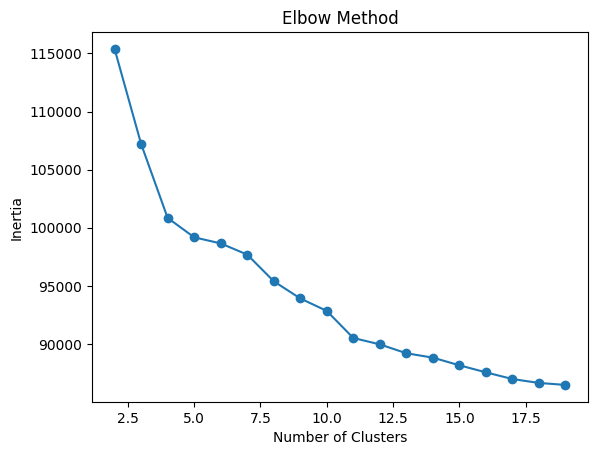

In [109]:
plt.plot(k_range, inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

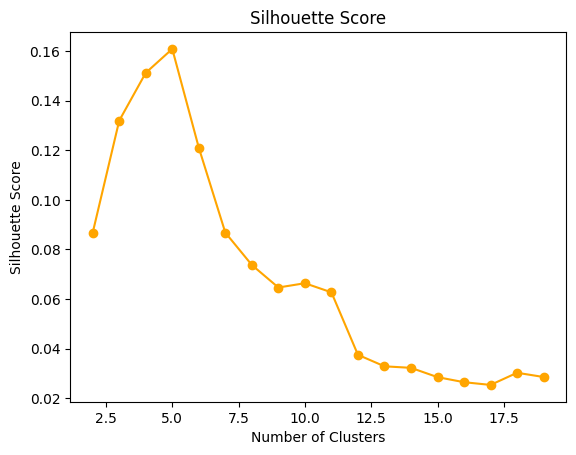

In [110]:
plt.plot(k_range, silhouette_scores, marker='o', color='orange')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

In [111]:
best_k = list(k_range)[silhouette_scores.index(max(silhouette_scores))]
print("best k:", best_k)

best k: 5


In [112]:
Kmedoids_model = KMedoids(n_clusters=best_k, metric="manhattan",init="random")
Kmedoids_model.fit(data)

,n_clusters,5
,metric,'manhattan'
,method,'alternate'
,init,'random'
,max_iter,300
,random_state,None


In [113]:
centers = Kmedoids_model.medoid_indices_
print("centers: ", centers)

centers:  [8551  536 3273 1827 5652]


# Task 4: Hierarchical Clustering

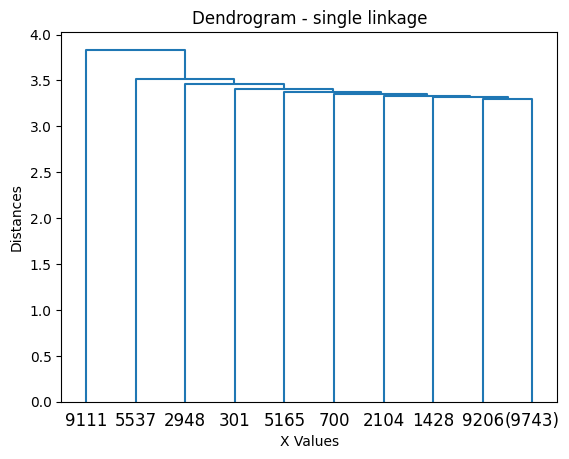

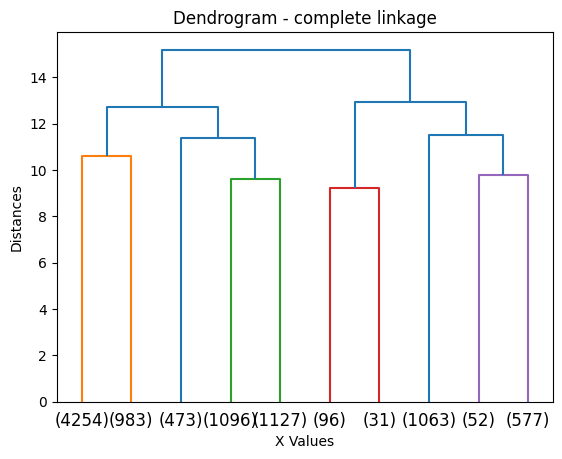

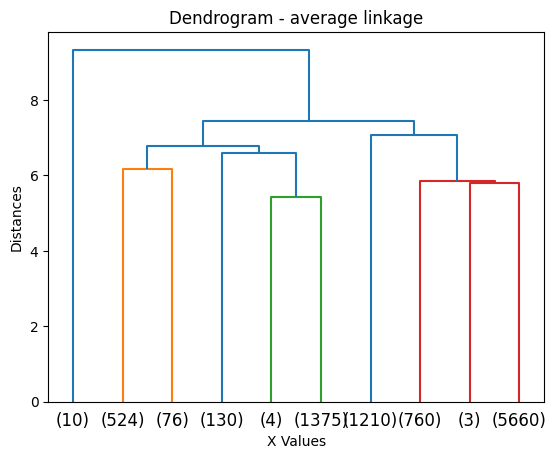

In [114]:
for method in ['single', 'complete', 'average']:
    dendrogram = sch.dendrogram(sch.linkage(data, method), truncate_mode='lastp', p=10)
    plt.title(f'Dendrogram - {method} linkage')
    plt.xlabel('X Values')
    plt.ylabel('Distances')
    plt.show()

In [115]:
inertias = []
silhouette_scores = []
k_range = range(2, 20)

for k in k_range:
    model = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    labels = model.fit_predict(data)
    silhouette_scores.append(silhouette_score(data, labels))

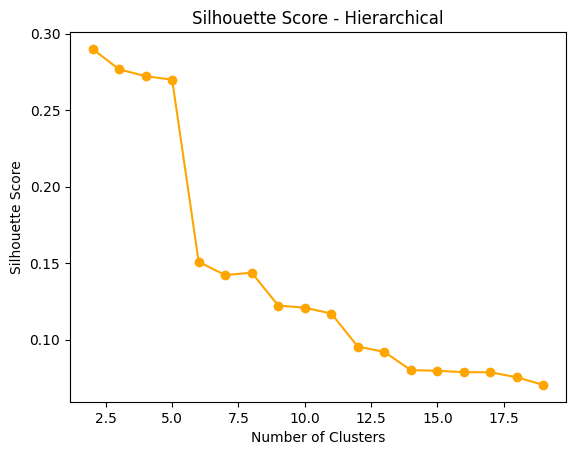

Best K: 2


In [116]:
plt.plot(k_range, silhouette_scores, marker='o', color='orange')
plt.title('Silhouette Score - Hierarchical')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

best_k = list(k_range)[silhouette_scores.index(max(silhouette_scores))]
print("Best K:", best_k)

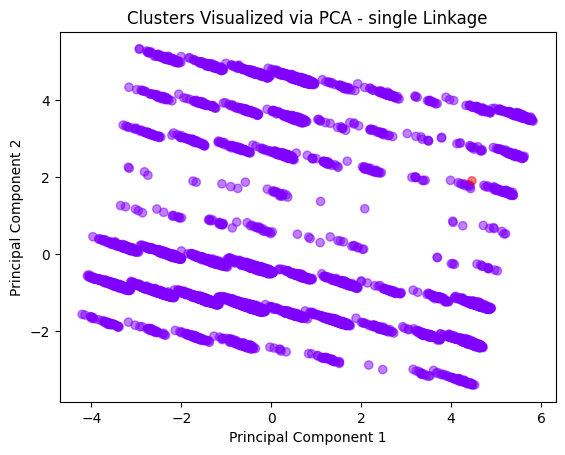

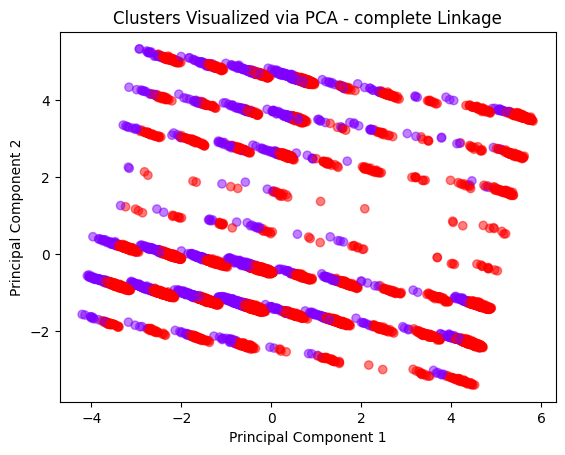

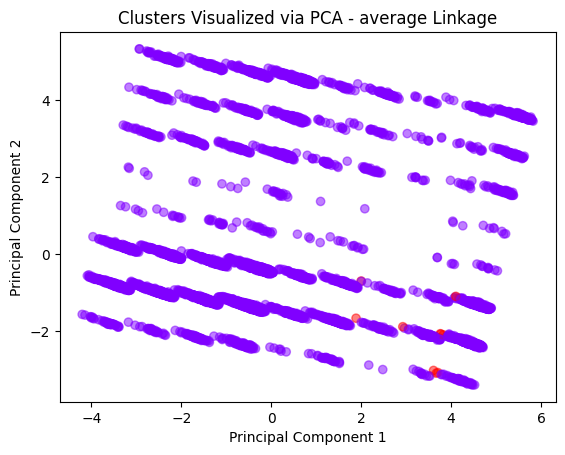

In [117]:
Hcluster = {}
Hlabels = {}

for method in ['single', 'complete', 'average']:
    Hcluster[method] = AgglomerativeClustering(n_clusters=best_k, metric='euclidean', linkage=method)
    Hlabels[method] = Hcluster[method].fit_predict(data)
    pca_2d = PCA(n_components=2)
    data_2d = pca_2d.fit_transform(data)
    plt.scatter(data_2d[:,0], data_2d[:,1], c=Hlabels[method], cmap='rainbow', alpha=0.5)
    plt.title(f'Clusters Visualized via PCA - {method} Linkage')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.show()
